In [ ]:
#NEW
#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("PIXE_Intensities.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from PIXE_functions import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.2f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PIXE_Intensities.ipynb started: Tue, 24 Mar 2026 09:32:39
INFO: SETUP COMPLETE (1484.38 ms)
---------------------------------------


In [2]:
def read_json_formatted_file(filepath, encoding="utf-8"):
    """
    Reads a file whose contents are JSON-formatted, regardless of file extension.

    Parameters:
        filepath (str): Path to the file
        encoding (str): File encoding (default: utf-8)

    Returns:
        dict or list: Parsed JSON content

    Raises:
        ValueError: If the file content is not valid JSON
        OSError: If the file cannot be read
    """
    with open(filepath, "r", encoding=encoding) as f:
        content = f.read()

    try:
        return json.loads(content)
    except json.JSONDecodeError as e:
        raise ValueError(f"File content is not valid JSON: {e}") from e
    
def file_collector(measurement:str):
    file_collection = []
    top_level_path = f'.//{measurement}'
    for file in os.listdir(top_level_path):
        if (file[-5:] == '.vspc'):
            full_path = top_level_path + '//' + file
            file_collection.append(full_path)
    return file_collection

def pixe_single_spectrum_plot(filename:str):
    '''
    This function will produce a simple labeled plot of uncalibrated raw-data.
    '''
    DPI = 250
    data = read_json_formatted_file(filename)
    meas_name = filename.split('//')[2].split('.')[0]
    meas_folder = filename.split('//')[1]
    
    energyPerBin = data['Calibration']['BinSize_keV/Bin'] # keV/bin
    bin_data = data['RawData'][:-1] #remove that overflow bin at position 8191
    total_counts = np.sum(bin_data)
    total_counts_incl = np.sum(data['RawData'])
    # print(bin_data)
    
    bins = np.arange(0,len(bin_data),1)
    
    scatter_color = color_schemes['c_dark']
    
    fig, ax = plt.subplots(figsize=(6,3), dpi=DPI)
    # ax.set_facecolor(color_schemes['c_back'])
    # ax.plot(bins, bin_data, lw=0.75, color=scatter_color[0], zorder=2)
    ax.step(bins, bin_data, lw=0.75, color=scatter_color[3], zorder=2)
    
    if (len(bin_data) == 8191):
        ax.set_xlim(0,8193)
        ax.set_xticks(np.arange(0,8193,1024),np.arange(0,8193,1024))
    elif (len(bin_data) == 4095):
        ax.set_xlim(0,4095)
        ax.set_xticks(np.arange(0,4097,512),np.arange(0,4097,512))
    elif (len(bin_data) == 2047):
        ax.set_xlim(0,2047)
        ax.set_xticks(np.arange(0,2049,512),np.arange(0,2049,512))
        
        
    plt.xlabel('MCA channel')
    plt.ylabel('Counts')
    
    plt.grid(which="both")
    plt.tight_layout()

    #----------------- Information Box -----------------#
    #det_pic_file = detector_pic(measurement['det_id'])
    # img = plt.imread(det_pic_file)
    annotation = TextArea(f"X-ray measurement \n {meas_name} \n RAW DATA \n Total Counts: {total_counts}", textprops=dict(color="black", fontsize=5, multialignment='center'))
    # imagebox = OffsetImage(img, zoom=0.05)
    stacked = VPacker(children=[annotation],
                 align="center",
                 pad=0,
                 sep=5)
    
    ab = AnnotationBbox(offsetbox=stacked, xy=(0.9,0.85), xycoords='axes fraction', frameon=True)

    ax.add_artist(ab)
    #----------------- Information Box -----------------#

    
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}.png', dpi=DPI)
    plt.savefig(f'./plots/uncalibrated/{meas_folder}/{meas_name}.pdf', dpi=DPI)
    
    plt.show()

def all_files_from_measSet(m_name:str):
    f_c = file_collector(m_name)
    for file in f_c:
        pixe_single_spectrum_plot(file)
    return 4

## Measurement Intensity Calculations

In [228]:
df = pd.read_csv('measured_Lines_database.csv', sep=',', header=0)

def Kb1_Ka1_fromData(df,elem):
    
    N_line, N_min_line, N_max_line = [], [], []
    for i in range(len(df)):
        if (df.loc[i,'element'] == elem and df.loc[i,'line_name'] in ['Ka1','Kb1']):
            m_list = df.loc[i,:].values.tolist()
            param = [m_list[6], m_list[7], m_list[8]]
            param_min = [m_list[6]-m_list[9], m_list[7]-m_list[10], m_list[8]-m_list[11]]
            param_max = [m_list[6]+m_list[9], m_list[7]+m_list[10], m_list[8]+m_list[11]]
            x_lin = np.linspace(m_list[7]-3*m_list[8], m_list[7]+3*m_list[8], 1000)
            N_line.append(np.sum(gauss_func(param, x_lin)))
            N_min_line.append(np.sum(gauss_func(param_min, x_lin)))
            N_max_line.append(np.sum(gauss_func(param_max, x_lin)))
            print(m_list)
    for i in range(0, len(N_line),2):
        fit_val = N_line[i+1]/N_line[i]
        fit_min_val = N_min_line[i+1]/N_min_line[i]
        fit_max_val = N_max_line[i+1]/N_max_line[i]
        print(f'------------------{elem} {i}------------------')
        print('fit', fit_val)
        print('min', fit_min_val)
        print('max', fit_max_val)
        print(f'Result for plot >>> {round(fit_val,4)} +{round(fit_max_val-fit_val,4)} -{round(fit_val-fit_min_val,4)}')
        print(f'----------------------------------------')

### Mangenese

In [229]:
#Mangenese_Kb1_Ka1
Kb1_Ka1_fromData(df,elem='Mn')

### Copper

In [230]:
#Copper_Kb1_Ka1
Kb1_Ka1_fromData(df,elem='Cu')

['Cu', 'Ka1', 'KL_3', np.int64(4096), np.int64(5461), 'PIXE Amersham Source Set B', np.float64(129.278), np.float64(1698.362), np.float64(13.062), np.float64(3.509), np.float64(0.369), np.float64(0.233), 'Ka2']
['Cu', 'Kb1', 'KM_3', np.int64(4096), np.int64(5461), 'PIXE Amersham Source Set B', np.float64(21.095), np.float64(1880.149), np.float64(13.326), np.float64(2.328), np.float64(1.277), np.float64(0.975), 'x']
['Cu', 'Ka1', 'KL_3', np.int64(8192), np.int64(10922), 'PIXE Amersham Source Set B', np.float64(10.237), np.float64(3397.287), np.float64(23.43), np.float64(0.219), np.float64(0.429), np.float64(0.349), 'Ka2']
['Cu', 'Kb1', 'KM_3', np.int64(8192), np.int64(10922), 'PIXE Amersham Source Set B', np.float64(10.158), np.float64(3764.867), np.float64(31.106), np.float64(0.113), np.float64(3.601), np.float64(3.629), 'x']
------------------Cu 0------------------
fit 0.1631754822939706
min 0.14094955286708424
max 0.18558625418271732
Result for plot >>> 0.1632 +0.0224 -0.0222
-------

### Rubidium

In [231]:
#Rubidium_Kb1_Ka1
Kb1_Ka1_fromData(df,elem='Rb')

['Rb', 'Ka1', 'KL_3', np.int64(4096), np.int64(5461), 'PIXE Amersham Source Set B', np.float64(312.16), np.float64(2823.541), np.float64(17.656), np.float64(6.715), np.float64(0.418), np.float64(0.254), 'Ka2']
['Rb', 'Kb1', 'KM_3', np.int64(4096), np.int64(5461), 'PIXE Amersham Source Set B', np.float64(53.558), np.float64(3157.904), np.float64(17.52), np.float64(5.067), np.float64(2.803), np.float64(1.889), 'Kb3']
['Rb', 'Ka1', 'KL_3', np.int64(8192), np.int64(10922), 'PIXE Amersham Source Set B', np.float64(23.009), np.float64(5648.343), np.float64(33.532), np.float64(0.335), np.float64(0.407), np.float64(0.313), 'Ka2']
['Rb', 'Kb1', 'KM_3', np.int64(8192), np.int64(10922), 'PIXE Amersham Source Set B', np.float64(1.851), np.float64(6297.683), np.float64(4.632), np.float64(0.631), np.float64(1.815), np.float64(1.718), 'x']
------------------Rb 0------------------
fit 0.1715722706304456
min 0.1439078359035636
max 0.19993570880427364
Result for plot >>> 0.1716 +0.0284 -0.0277
---------

### Molybdenium

In [232]:
#Molybdenum_Kb1_Ka1
Kb1_Ka1_fromData(df,elem='Mo')

['Mo', 'Ka1', 'KL_3', np.int64(4096), np.int64(5461), 'PIXE Amersham Source Set B', np.float64(550.83), np.float64(2760.658), np.float64(16.614), np.float64(13.854), np.float64(0.517), np.float64(0.294), 'Ka2']
['Mo', 'Kb1', 'KM_3', np.int64(4096), np.int64(5461), 'PIXE Amersham Source Set B', np.float64(97.584), np.float64(3102.089), np.float64(15.271), np.float64(10.566), np.float64(1.759), np.float64(1.286), 'Kb3']
['Mo', 'Ka1', 'KL_3', np.int64(8192), np.int64(10922), 'PIXE Amersham Source Set B', np.float64(27.659), np.float64(7363.273), np.float64(40.826), np.float64(0.294), np.float64(0.363), np.float64(0.273), 'Ka2']
['Mo', 'Ka1', 'KL_3', np.int64(8192), np.int64(2730), 'PIXE Amersham Source Set B', np.float64(113.454), np.float64(1840.662), np.float64(10.868), np.float64(3.361), np.float64(0.332), np.float64(0.211), 'Ka2']
['Mo', 'Kb1', 'KM_3', np.int64(8192), np.int64(2730), 'PIXE Amersham Source Set B', np.float64(21.66), np.float64(2068.668), np.float64(9.396), np.float64(2

IndexError: list index out of range

### Silver

In [233]:
#Silver_Kb1_Ka1
Kb1_Ka1_fromData(df,elem='Ag')

['Ag', 'Ka1', 'KL_3', np.int64(8192), np.int64(2730), 'PIXE Amersham Source Set B', np.float64(89.173), np.float64(2331.421), np.float64(13.401), np.float64(2.352), np.float64(0.351), np.float64(0.229), 'Ka2']
['Ag', 'Kb1', 'KM_3', np.int64(8192), np.int64(2730), 'PIXE Amersham Source Set B', np.float64(16.724), np.float64(2630.642), np.float64(11.079), np.float64(2.13), np.float64(1.252), np.float64(0.959), 'Kb3']
------------------Ag 0------------------
fit 0.1875455575118023
min 0.15639311332059413
max 0.21944756281198374
Result for plot >>> 0.1875 +0.0319 -0.0312
----------------------------------------


### Barium

In [234]:
#Barium_Kb1_Ka1
Kb1_Ka1_fromData(df,elem='Ba')

['Ba', 'Ka1', 'KL_3', np.int64(8192), np.int64(2730), 'PIXE Amersham Source Set B', np.float64(1.111), np.float64(3347.507), np.float64(9.061), np.float64(0.222), np.float64(2.151), np.float64(0.172), 'x']
['Ba', 'Kb1', 'KM_3', np.int64(8192), np.int64(2730), 'PIXE Amersham Source Set B', np.float64(1.45), np.float64(3394.324), np.float64(16.159), np.float64(0.172), np.float64(2.161), np.float64(2.263), 'x']
------------------Ba 0------------------
fit 1.3051305130513082
min 1.2631094725859178
max 1.354769518979522
Result for plot >>> 1.3051 +0.0496 -0.042
----------------------------------------


### Terbium

In [235]:
#Terbium_Kb1_Ka1
Kb1_Ka1_fromData(df,elem='Tb')

['Tb', 'Ka1', 'KL_3', np.int64(8192), np.int64(2730), 'PIXE Amersham Source Set B', np.float64(2.855), np.float64(4612.223), np.float64(17.694), np.float64(0.371), np.float64(2.104), np.float64(1.995), 'x']
['Tb', 'Kb1', 'KM_3', np.int64(8192), np.int64(2730), 'PIXE Amersham Source Set B', np.float64(1.101), np.float64(5305.89), np.float64(21.779), np.float64(0.219), np.float64(4.59), np.float64(4.55), 'Kb3']
------------------Tb 0------------------
fit 0.3856392294220664
min 0.31676460453073135
max 0.4413608921502884
Result for plot >>> 0.3856 +0.0557 -0.0689
----------------------------------------


### Gold

In [236]:
#Gold_Kb1_Ka1
Kb1_Ka1_fromData(df,elem='Au')

## $K_{\beta}/ K_{\alpha}$ Ratio

In [169]:
K_name = ['Ertugral et al. (2006)', 'Ertugral et al. (2006)', 'Scofield (1974a)', 'Scofield (1974b)', 'Mason \& Kennedy (1974)', 'Salem et al. (1974)', 'Ertugrul et al. (2001)', 'Set A (26.02.2026)', 'Set B (27.02.2026)']
# K_additions = ['exp. values', 'fit. values', 'theo. values (Hartree-Fock)', 'theo. values (Hartree-Slater)', 'theo. values (Hartree-Slater)', 'exp. values', 'exp. values']
K_additions = ['exp. values', 'fit. values', '(Hartree-Fock)', '(Hartree-Slater)', '(Hartree-Slater)', 'exp. values', 'exp. values', 'Amptek Mini-X', 'Amersham 2084']
K_x_index = [1.6,2.4,0.8,1.0,1.2,1.8,2.0,0.0,0.2]
K_scatter = ['x','o','h','<','>','s','D','^','v']
Kb1_Ka1 = {'Mn':[0.1440,0.1293,0.1385,0.1195,0.1194,-1,0.131,-1,-1],
           'Ni':[0.1330,0.1448,0.1401,0.1227,0.1221,0.135,0.135,-1,-1],
           'Cu':[0.1359,0.1496,0.1379,0.1216,0.1208,-1,0.134,-1,-1],
           'Rb':[0.1806,0.1824,0.1780,0.1600,0.1590,-1,0.171,-1,-1],
           'Mo':[0.2016,0.1986,0.1981,0.1809,0.1794,0.197,0.193,-1,-1],
           'Ag':[0.2096,0.2123,0.2130,0.1964,0.1944,-1,0.217,-1,-1],
           'Ba':[0.2472,0.2323,0.2433,0.2273,0.2246,0.237,0.235,-1,-1],
           'Tb':[0.2515,0.2494,0.2575,0.2435,0.2389,-1,0.259,-1,-1],
           'Au':[0.2680,0.2783,0.2772,0.2646,0.2548,-1,-1,-1,-1]}
Kb1_Ka1_err = {'Mn':[0.004,0,0,0,0,0,0.013,0,0],
               'Ni':[0.003,0,0,0,0,0.135*0.02,0.012,0,0],
               'Cu':[0.003,0,0,0,0,0,0.012,0,0],
               'Rb':[0.007,0,0,0,0,0,0.015,0,0],
               'Mo':[0.004,0,0,0,0,0.197*0.02,0.014,0,0],
               'Ag':[0.004,0,0,0,0,0,0.015,0,0],
               'Ba':[0.005,0,0,0,0,0.237*0.02,0.017,0,0],
               'Tb':[0.007,0,0,0,0,0,0.021,0,0],
               'Au':[0.005,0,0,0,0,0,0,0,0]}

<>:1: SyntaxWarning: invalid escape sequence '\&'
<>:1: SyntaxWarning: invalid escape sequence '\&'
C:\Users\schum\AppData\Local\Temp\ipykernel_17224\139780587.py:1: SyntaxWarning: invalid escape sequence '\&'
  K_name = ['Ertugral et al. (2006)', 'Ertugral et al. (2006)', 'Scofield (1974a)', 'Scofield (1974b)', 'Mason \& Kennedy (1974)', 'Salem et al. (1974)', 'Ertugrul et al. (2001)', 'Set A (26.02.2026)', 'Set B (27.02.2026)']


In [172]:
def Kb1_Ka1_perElement(element:str, K_n:list, K_add:list, Kb1_Ka1:dict, Kb1_Ka1_err:dict, K_scatter:list, K_x_index:list):
    DPI = 300
    plt.figure(figsize=(5,3), dpi=DPI)
    data = Kb1_Ka1[element]
    errors = Kb1_Ka1_err[element]
    
    plt.title(f'{element} - $K_\\beta/K_\\alpha$ ratio')
    plt.ylabel(r'$K_{\beta}/K_{\alpha}$')
    
    plt.ylim(0.6*np.max(data),1.1*np.max(data))
    plt.xticks([])
    
    plt.fill_between(x=[-0.1,0.5], y1=0, y2=1, color=color_schemes['c_light'][5], alpha=0.4, zorder=1)
    plt.fill_between(x=[0.7,1.3], y1=0, y2=1, color=color_schemes['c_light'][0], alpha=0.4, zorder=1)
    plt.fill_between(x=[1.5,2.1], y1=0, y2=1, color=color_schemes['c_light'][4], alpha=0.4, zorder=1)
    plt.fill_between(x=[2.3,2.5], y1=0, y2=1, color=color_schemes['c_light'][2], alpha=0.4, zorder=1)
    
    plt.text(0.2, 1.07*np.max(data), 'Measurement', fontsize=8, color='black', ha='center', va='center')
    plt.text(1.0, 1.07*np.max(data), 'Theory', fontsize=8, color='black', ha='center', va='center')
    plt.text(1.8, 1.07*np.max(data), 'Experiment', fontsize=8, color='black', ha='center', va='center')
    plt.text(2.4, 1.07*np.max(data), 'Fitted', fontsize=8, color='black', ha='center', va='center')
    
    for i in range(len(data)):
        if (data[i] != -1):
            plt.errorbar(x=K_x_index[i],y=data[i],yerr=errors[i],markersize=3,capsize=2,fmt='',lw=0,elinewidth=0.6,ecolor='black',color='black',marker=K_scatter[i])
            
            if (i == 0):
                plt.text(1.6, data[0]-0.01, K_n[0], rotation=90, fontsize=5, color='black', ha='center', va='top')
            elif (i == 1):
                plt.text(2.4, data[1]-0.01, K_n[1], rotation=90, fontsize=5, color='black', ha='center', va='top')
            elif (i == 2):
                plt.text(0.8, data[2]-0.005, f'{K_n[2]} \n {K_add[2]}', rotation=90, fontsize=5, color='black', ha='center', va='top')
            elif (i == 3):
                plt.text(1.2, data[3]-0.015, f'{K_n[3]} \n {K_add[3]}', rotation=90, fontsize=5, color='black', ha='center', va='top')
            elif (i == 4):
                plt.text(1.0, data[4]-0.005, f'{K_n[4]} \n {K_add[4]}', rotation=90, fontsize=5, color='black', ha='center', va='top')
            elif (i == 5):
                plt.text(1.8, data[5]-0.01, f'{K_n[5]}', rotation=90, fontsize=5, color='black', ha='center', va='top')
            elif (i == 6):
                plt.text(2.0, data[6]-(data[6]*0.12), f'{K_n[6]}', rotation=90, fontsize=5, color='black', ha='center', va='top')
                
                
            if (K_scatter[i] == 'x'):
                plt.scatter([],[],s=8,lw=1,marker=K_scatter[i],color='black',label=f'{K_n[i]} \n {K_add[i]}')
            else:
                plt.scatter([],[],s=8,lw=0.5,marker=K_scatter[i],color='black',label=f'{K_n[i]} \n {K_add[i]}')
    
    plt.tight_layout()
    plt.savefig(f'./intensities/{element}_Kb1_Ka1.png', dpi=DPI)
    plt.savefig(f'./intensities/{element}_Kb1_Ka1.pdf', dpi=DPI)
    plt.show()

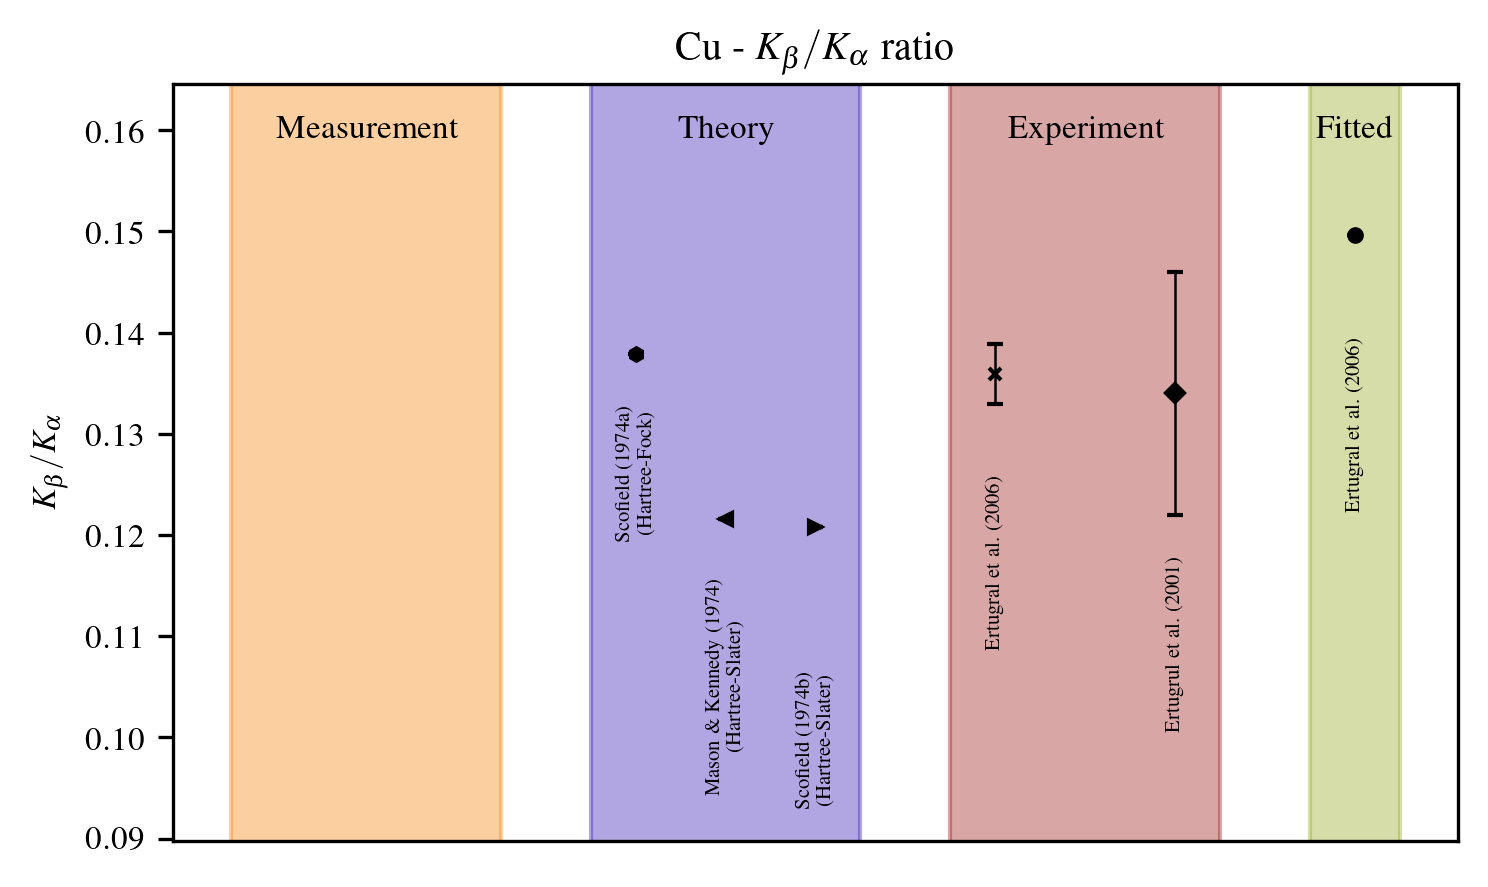

In [173]:
Kb1_Ka1_perElement('Cu', K_name, K_additions, Kb1_Ka1, Kb1_Ka1_err, K_scatter, K_x_index)
# for elem in Kb1_Ka1.keys():
#     Kb1_Ka1_perElement(elem, K_name, K_additions, Kb1_Ka1, Kb1_Ka1_err, K_scatter, K_x_index)